# 🦁 MUFASAR — Reliable Reasoning Model Benchmark
**Africa Deep Tech Challenge 2026 · CPU-only**

| Model | Runtime | Benchmark coverage |
|---|---|---|
| Qwen3-4B Thinking | `llama-cpp-python` | common micro-test + full five-question suite |
| Phi-4 Mini Reasoning | `llama-cpp-python` | common micro-test + full five-question suite |
| Gemma 3 4B IT | `llama-cpp-python` | common micro-test + full five-question suite |
| Nanbeige4.2-3B | official Nanbeige `llama.cpp` fork | common micro-test + full five-question suite |
| Ternary Bonsai 27B + DSpark | PrismML `llama.cpp` fork | common micro-test; target-only/native-bench fallback |

### Reliability changes

- Nanbeige filenames are resolved from the Hub dynamically, with a second GGUF repository as fallback.
- Nanbeige uses the required `nanbeige42` runtime instead of stock `llama-cpp-python`.
- Every model runs the same short `COMMON-MICRO` test, which is used for the cross-model chart.
- The smaller models also run the original five-question reasoning suite.
- Ternary Bonsai first attempts target + DSpark. On CPU it uses only the common micro-test and eight generated tokens so it completes in practical time.
- If DSpark serving fails, the notebook retries target-only serving and then native `llama-bench` rather than dropping Bonsai.
- No participant metadata, submission schema, or profiler metadata is created.
- Model files are deleted after each benchmark to reclaim disk.

> Enable **Internet** in Kaggle before running all cells.


In [1]:
import subprocess, sys

# Avoid upgrading Kaggle's core pandas/matplotlib stack unnecessarily.
pkgs = [
    "llama-cpp-python>=0.3.8,<0.4",
    "huggingface_hub>=0.30,<2",
    "psutil>=5.9",
    "requests>=2.31",
    "tabulate>=0.9",
]
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--prefer-binary"
] + pkgs)
print("✅ Runtime packages installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
✅ Runtime packages installed


In [2]:
import os, gc, re, time, json, warnings, shutil, socket, threading, subprocess, fnmatch
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import requests
import matplotlib.pyplot as plt
from huggingface_hub import HfApi, hf_hub_download
from llama_cpp import Llama

warnings.filterwarnings("ignore")

WORK_DIR = Path("/kaggle/working")
MODEL_DIR = WORK_DIR / "models"
ARTIFACT_DIR = WORK_DIR / "mufasar_artifacts"
NANBEIGE_LLAMA_DIR = WORK_DIR / "nanbeige-llama.cpp"
NANBEIGE_BUILD_DIR = NANBEIGE_LLAMA_DIR / "build"
PRISM_LLAMA_DIR = WORK_DIR / "prism-llama.cpp"
PRISM_BUILD_DIR = PRISM_LLAMA_DIR / "build"

for directory in (MODEL_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

N_THREADS = max(1, min(8, os.cpu_count() or 4))
RAM_BUDGET_MB = 8 * 1024
DELETE_MODEL_AFTER_BENCHMARK = True

os.environ.update({
    "OMP_NUM_THREADS": str(N_THREADS),
    "OPENBLAS_NUM_THREADS": str(N_THREADS),
    "MKL_NUM_THREADS": str(N_THREADS),
    "NUMEXPR_NUM_THREADS": str(N_THREADS),
    "TOKENIZERS_PARALLELISM": "false",
    "HF_HUB_DOWNLOAD_TIMEOUT": "300",
    "HF_HUB_ETAG_TIMEOUT": "90",
    "HF_HUB_DISABLE_XET": "0",
})

print(f"CPU threads: {N_THREADS} | nominal RAM target: {RAM_BUDGET_MB} MB")
print(f"Delete models after benchmark: {DELETE_MODEL_AFTER_BENCHMARK}")


CPU threads: 4 | nominal RAM target: 8192 MB
Delete models after benchmark: True


In [3]:
MODELS = {
    "Qwen3-4B-Thinking": {
        "repo_candidates": [
            {"repo": "Qwen/Qwen3-4B-GGUF", "filename": "Qwen3-4B-Q4_K_M.gguf"},
        ],
        "template": "qwen3",
        "stop": ["<|im_end|>"],
        "thinking": True,
        "backend": "python",
        "color": "#E87D2E",
    },
    "Phi-4-Mini-Reasoning": {
        "repo_candidates": [
            {"repo": "Mungert/Phi-4-mini-reasoning-GGUF", "filename": "Phi-4-mini-reasoning-q4_k_m.gguf"},
        ],
        "template": "phi4",
        "stop": ["<|end|>", "<|endoftext|>"],
        "thinking": False,
        "backend": "python",
        "color": "#0078D4",
    },
    "Gemma-3-4B-IT": {
        "repo_candidates": [
            {"repo": "lmstudio-community/gemma-3-4b-it-GGUF", "filename": "gemma-3-4b-it-Q4_K_M.gguf"},
        ],
        "template": "gemma",
        "stop": ["<end_of_turn>"],
        "thinking": False,
        "backend": "python",
        "color": "#34A853",
    },
    "Nanbeige4.2-3B-Q4_K_M": {
        # The first repo has a stable exact filename. The second is retained as a
        # dynamically resolved fallback in case one mirror is temporarily unavailable.
        "repo_candidates": [
            {"repo": "Abiray/Nanbeige4.2-3B-GGUF", "filename": "Nanbeige4.2-3B-Q4_K_M.gguf"},
            {"repo": "owao/Nanbeige4.2-3B-GGUF", "pattern": "*Q4_K_M.gguf"},
        ],
        "template": "nanbeige",
        "stop": ["<|im_end|>", "<|endoftext|>"],
        "thinking": True,
        "backend": "nanbeige_server",
        "ctx_size": 2048,
        "n_batch": 128,
        "full_max_tokens": 256,
        "color": "#9B59B6",
    },
    "Ternary-Bonsai-27B-DSpark": {
        "repo_candidates": [
            {"repo": "prism-ml/Ternary-Bonsai-27B-gguf", "filename": "Ternary-Bonsai-27B-Q2_0.gguf"},
        ],
        "draft_candidates": [
            {"repo": "prism-ml/Ternary-Bonsai-27B-gguf", "filename": "Ternary-Bonsai-27B-dspark-Q4_1.gguf"},
        ],
        "template": "bonsai",
        "stop": ["<|im_end|>", "<|endoftext|>"],
        "thinking": True,
        "backend": "prism_dspark",
        "ctx_size": 256,
        "n_batch": 32,
        "micro_only": True,
        "micro_max_tokens": 8,
        "color": "#D4AF37",
    },
}

COMMON_MICRO = [{
    "id": "COMMON-MICRO",
    "domain": "Common micro-test",
    "scope": "common_micro",
    "q": "Calculate 18 multiplied by 35. Give only the calculation and final number.",
}]

FULL_QUESTIONS = [
    {
        "id": "MATH-01", "domain": "Agriculture Math", "scope": "full_suite",
        "q": (
            "A farmer in Kano, Nigeria plants maize on 4 hectares. Each hectare yields "
            "2.8 tonnes. He sells 70% of the harvest at ₦85,000 per tonne and stores "
            "the rest. Calculate his total revenue and the mass stored."
        ),
    },
    {
        "id": "SCI-01", "domain": "Climate Science", "scope": "full_suite",
        "q": (
            "The Sahel region is experiencing desertification. Describe the positive "
            "feedback loop between vegetation loss and reduced rainfall, then propose "
            "two evidence-based reforestation strategies used successfully in Africa."
        ),
    },
    {
        "id": "MATH-02", "domain": "Public Health Math", "scope": "full_suite",
        "q": (
            "A malaria study in Ghana found a prevalence rate of 23% among children "
            "under 5. The district has 14,800 such children. If treatment costs $4.20 "
            "per child, what is the total treatment cost in USD and GHS at 15.2 GHS/USD?"
        ),
    },
    {
        "id": "SCI-02", "domain": "Soil Science", "scope": "full_suite",
        "q": (
            "Explain why nitrogen-fixing legumes such as cowpea are intercropped with "
            "maize across sub-Saharan Africa. Include the biochemical mechanism and "
            "a typical kg N/ha contribution per season."
        ),
    },
    {
        "id": "MATH-03", "domain": "Energy Math", "scope": "full_suite",
        "q": (
            "A solar micro-grid in rural Kenya has 12 panels rated at 300 W. Average "
            "daily sunshine is 5.5 hours. If a household needs 3.6 kWh/day, how many "
            "households can the micro-grid serve? Show the calculation."
        ),
    },
]

BM_CFG = {
    "full_max_tokens": 256,
    "micro_max_tokens": 8,
    "temperature": 0.0,
    "top_p": 0.95,
    "top_k": 20,
    "ctx_size": 4096,
    "n_batch": 256,
    "repeat_penalty": 1.1,
    "request_timeout_s": 3600,
    "server_start_timeout_s": 1200,
}

print("✅ Model registry and benchmark workloads loaded")


✅ Model registry and benchmark workloads loaded


In [4]:
def make_prompt(template, question):
    system_prompt = "You are MUFASAR, an African scientific reasoning assistant. Think carefully."
    if template in {"qwen3", "nanbeige", "bonsai"}:
        return (
            f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
            f"<|im_start|>user\n{question}<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )
    if template == "phi4":
        return (
            f"<|system|>\n{system_prompt}<|end|>\n"
            f"<|user|>\n{question}<|end|>\n"
            f"<|assistant|>\n"
        )
    if template == "gemma":
        return (
            f"<start_of_turn>user\n{system_prompt}\n\n{question}<end_of_turn>\n"
            f"<start_of_turn>model\n"
        )
    raise ValueError(f"Unsupported prompt template: {template}")


def count_thinking_tokens(text, tokenizer=None):
    """Count an open or closed <think> block; max-token truncation no longer returns zero."""
    start = text.find("<think>")
    if start < 0:
        return 0
    start += len("<think>")
    end = text.find("</think>", start)
    payload = text[start:] if end < 0 else text[start:end]
    if tokenizer is not None:
        try:
            return len(tokenizer.tokenize(payload.encode("utf-8")))
        except Exception:
            pass
    return len(payload.split())


def release_memory():
    gc.collect()
    try:
        import ctypes
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass


def remove_model_file(path):
    if not DELETE_MODEL_AFTER_BENCHMARK or not path:
        return
    try:
        path = Path(path)
        if path.exists() and path.is_file():
            path.unlink()
            print(f"  Deleted model file: {path.name}")
    except Exception as exc:
        print(f"  Could not delete {path}: {exc}")


def run_checked(command, *, cwd=None, timeout=None, log_path=None):
    command = [str(value) for value in command]
    print("$", " ".join(command), flush=True)
    completed = subprocess.run(
        command,
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    output = completed.stdout or ""
    if log_path:
        Path(log_path).write_text(output, encoding="utf-8")
    if completed.returncode != 0:
        tail = "\n".join(output.splitlines()[-100:])
        raise RuntimeError(
            f"Command failed with exit code {completed.returncode}: {' '.join(command)}\n{tail}"
        )
    return output


def resolve_hub_file(candidates, label):
    """Resolve exact/case-varying Hub filenames and try alternate mirrors."""
    api = HfApi()
    errors = []
    for candidate in candidates:
        repo = candidate["repo"]
        wanted = candidate.get("filename")
        pattern = candidate.get("pattern")
        try:
            repo_files = api.list_repo_files(repo_id=repo, revision="main")
            chosen = None
            if wanted:
                exact = [name for name in repo_files if name == wanted]
                insensitive = [name for name in repo_files if name.lower() == wanted.lower()]
                chosen = (exact or insensitive or [None])[0]
            if chosen is None and pattern:
                matches = [name for name in repo_files if fnmatch.fnmatch(name.lower(), pattern.lower())]
                if matches:
                    matches.sort(key=lambda name: ("q4_k_m" not in name.lower(), len(name)))
                    chosen = matches[0]
            if chosen is None:
                raise FileNotFoundError(
                    f"No file matching {wanted or pattern!r} in {repo}; available GGUFs: "
                    f"{[x for x in repo_files if x.lower().endswith('.gguf')][:20]}"
                )
            print(f"Downloading {label}: {repo}/{chosen}")
            path = Path(hf_hub_download(
                repo_id=repo,
                filename=chosen,
                revision="main",
                local_dir=str(MODEL_DIR),
            ))
            if not path.exists() or path.stat().st_size < 50_000_000:
                raise OSError(f"Downloaded file is missing or too small: {path}")
            return path, repo, chosen
        except Exception as exc:
            errors.append(f"{repo}: {type(exc).__name__}: {exc}")
            print(f"  Mirror failed: {errors[-1]}")
    raise RuntimeError(f"Unable to resolve {label}. Attempts: {errors}")


def process_tree_rss_mb(pid):
    try:
        parent = psutil.Process(pid)
        total = parent.memory_info().rss
        for child in parent.children(recursive=True):
            try:
                total += child.memory_info().rss
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass
        return total / 1024**2
    except (psutil.NoSuchProcess, psutil.AccessDenied):
        return 0.0


def sample_peak_rss(pid, holder, interval=0.05):
    while holder["running"]:
        holder["peak"] = max(holder["peak"], process_tree_rss_mb(pid))
        time.sleep(interval)


def free_local_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.bind(("127.0.0.1", 0))
        return sock.getsockname()[1]


def wait_for_server(port, process, timeout_s, label):
    deadline = time.time() + timeout_s
    health_url = f"http://127.0.0.1:{port}/health"
    while time.time() < deadline:
        if process.poll() is not None:
            raise RuntimeError(f"{label} exited early with code {process.returncode}")
        try:
            response = requests.get(health_url, timeout=3)
            if response.status_code == 200:
                return
        except requests.RequestException:
            pass
        time.sleep(2)
    raise TimeoutError(f"{label} did not become ready within {timeout_s}s")


def terminate_process(process):
    if process is None or process.poll() is not None:
        return
    try:
        parent = psutil.Process(process.pid)
        children = parent.children(recursive=True)
        for item in children:
            item.terminate()
        parent.terminate()
        _, alive = psutil.wait_procs([parent] + children, timeout=15)
        for item in alive:
            item.kill()
    except Exception:
        try:
            process.kill()
        except Exception:
            pass


_BINARY_HELP_CACHE = {}


def binary_help(binary):
    key = str(binary)
    if key not in _BINARY_HELP_CACHE:
        try:
            completed = subprocess.run(
                [key, "--help"], text=True, stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT, timeout=30,
            )
            _BINARY_HELP_CACHE[key] = completed.stdout or ""
        except Exception:
            _BINARY_HELP_CACHE[key] = ""
    return _BINARY_HELP_CACHE[key]


def add_optional_flag(command, help_text, flag, value=None):
    if flag in help_text:
        command.append(flag)
        if value is not None:
            command.append(str(value))


def questions_for_model(cfg_model):
    return COMMON_MICRO if cfg_model.get("micro_only") else COMMON_MICRO + FULL_QUESTIONS


def max_tokens_for_question(cfg_model, question):
    if question["scope"] == "common_micro":
        return int(cfg_model.get("micro_max_tokens", BM_CFG["micro_max_tokens"]))
    return int(cfg_model.get("full_max_tokens", BM_CFG["full_max_tokens"]))


print("✅ Shared helper functions ready")


✅ Shared helper functions ready


In [5]:
def run_python_inference(llm, prompt, cfg, stop, max_tokens):
    pid = os.getpid()
    baseline = process_tree_rss_mb(pid)
    peak = {"peak": baseline, "running": True}
    sampler = threading.Thread(target=sample_peak_rss, args=(pid, peak), daemon=True)
    sampler.start()

    t0 = time.perf_counter()
    ttft = None
    chunks = []
    try:
        for chunk in llm.create_completion(
            prompt,
            max_tokens=max_tokens,
            temperature=cfg["temperature"],
            top_p=cfg["top_p"],
            top_k=cfg["top_k"],
            repeat_penalty=cfg["repeat_penalty"],
            stop=stop,
            stream=True,
        ):
            token = chunk["choices"][0].get("text", "")
            if token and ttft is None:
                ttft = time.perf_counter() - t0
            chunks.append(token)
    finally:
        total_s = time.perf_counter() - t0
        peak["running"] = False
        sampler.join(timeout=2)

    full_text = "".join(chunks)
    try:
        n_out = len(llm.tokenize(full_text.encode("utf-8")))
    except Exception:
        n_out = len(full_text.split())
    try:
        n_in = len(llm.tokenize(prompt.encode("utf-8")))
    except Exception:
        n_in = len(prompt.split())

    generation_s = max(total_s - (ttft or 0.0), 1e-9)
    return {
        "ttft_s": round(ttft or 0.0, 3),
        "total_s": round(total_s, 3),
        "tps": round(n_out / generation_s, 2) if n_out else 0.0,
        "prompt_tok": n_in,
        "output_tok": n_out,
        "peak_ram_mb": round(peak["peak"], 1),
        "ram_delta_mb": round(peak["peak"] - baseline, 1),
        "draft_tokens": 0,
        "draft_accepted": 0,
        "draft_acceptance": 0.0,
        "text": full_text,
    }


def benchmark_python_model(name, cfg_model):
    model_path, repo, filename = resolve_hub_file(cfg_model["repo_candidates"], name)
    size_gb = model_path.stat().st_size / 1e9
    print(f"\n{'=' * 72}\n{name} | {size_gb:.2f} GB | llama-cpp-python\n{'=' * 72}")

    llm = None
    results = []
    try:
        llm = Llama(
            model_path=str(model_path),
            n_ctx=cfg_model.get("ctx_size", BM_CFG["ctx_size"]),
            n_batch=cfg_model.get("n_batch", BM_CFG["n_batch"]),
            n_threads=N_THREADS,
            n_threads_batch=N_THREADS,
            n_gpu_layers=0,
            use_mmap=True,
            use_mlock=False,
            verbose=False,
        )
        _ = llm("Hello", max_tokens=2, echo=False, temperature=0.0)

        for question in questions_for_model(cfg_model):
            prompt = make_prompt(cfg_model["template"], question["q"])
            max_tokens = max_tokens_for_question(cfg_model, question)
            print(f"  [{question['id']}] {question['domain']} ({max_tokens} max) … ", end="", flush=True)
            result = run_python_inference(llm, prompt, BM_CFG, cfg_model["stop"], max_tokens)
            result["think_tok"] = count_thinking_tokens(result["text"], llm) if cfg_model["thinking"] else 0
            result.update(
                model=name,
                q_id=question["id"],
                domain=question["domain"],
                scope=question["scope"],
                backend="llama-cpp-python",
                status="ok",
                repo=repo,
                filename=filename,
            )
            print(f"TTFT {result['ttft_s']}s | {result['tps']} tok/s | RAM {result['peak_ram_mb']} MB")
            results.append(result)
        return results
    finally:
        if llm is not None:
            del llm
        release_memory()
        remove_model_file(model_path)
        print(f"  Unloaded. Free RAM: {psutil.virtual_memory().available / 1024**2:.0f} MB\n")


def build_fork(repo_url, branch, root, build_dir, targets, label):
    if not (root / ".git").exists():
        if root.exists():
            shutil.rmtree(root)
        clone_cmd = ["git", "clone", "--recursive", "--depth", "1"]
        if branch:
            clone_cmd += ["-b", branch]
        clone_cmd += [repo_url, root]
        run_checked(clone_cmd, timeout=900, log_path=ARTIFACT_DIR / f"{label}_clone.log")

    binaries = {target: build_dir / "bin" / target for target in targets}
    missing = [target for target, path in binaries.items() if not path.exists()]
    if missing:
        configure = [
            "cmake", "-S", root, "-B", build_dir,
            "-DGGML_CUDA=OFF",
            "-DGGML_NATIVE=ON",
            "-DGGML_CCACHE=OFF",
            "-DLLAMA_CURL=OFF",
            "-DLLAMA_BUILD_TESTS=OFF",
            "-DLLAMA_BUILD_EXAMPLES=ON",
            "-DLLAMA_BUILD_SERVER=ON",
            "-DCMAKE_BUILD_TYPE=Release",
        ]
        run_checked(configure, timeout=600, log_path=ARTIFACT_DIR / f"{label}_configure.log")
        run_checked(
            ["cmake", "--build", build_dir, "--config", "Release", "-j", str(max(1, min(4, N_THREADS))), "--target"] + targets,
            timeout=2400,
            log_path=ARTIFACT_DIR / f"{label}_build.log",
        )
    for target in targets:
        if not binaries[target].exists():
            matches = [path for path in build_dir.rglob(target) if path.is_file() and os.access(path, os.X_OK)]
            if matches:
                binaries[target] = matches[0]
        if not binaries[target].exists():
            raise FileNotFoundError(f"{label} build did not produce {target}")
    return binaries


def ensure_nanbeige_server():
    return build_fork(
        "https://github.com/Nanbeige/llama.cpp.git",
        "nanbeige42",
        NANBEIGE_LLAMA_DIR,
        NANBEIGE_BUILD_DIR,
        ["llama-server"],
        "nanbeige",
    )["llama-server"]


def ensure_prism_tools():
    return build_fork(
        "https://github.com/PrismML-Eng/llama.cpp.git",
        None,
        PRISM_LLAMA_DIR,
        PRISM_BUILD_DIR,
        ["llama-server", "llama-bench"],
        "prism",
    )


print("✅ Python and fork-build helpers ready")


✅ Python and fork-build helpers ready


In [6]:
def request_server_completion(process, port, prompt, cfg_model, question, backend_label):
    baseline = process_tree_rss_mb(process.pid)
    peak = {"peak": baseline, "running": True}
    sampler = threading.Thread(target=sample_peak_rss, args=(process.pid, peak), daemon=True)
    sampler.start()

    max_tokens = max_tokens_for_question(cfg_model, question)
    started = time.perf_counter()
    payload = None
    try:
        response = requests.post(
            f"http://127.0.0.1:{port}/completion",
            json={
                "prompt": prompt,
                "n_predict": max_tokens,
                "temperature": BM_CFG["temperature"],
                "top_p": BM_CFG["top_p"],
                "top_k": BM_CFG["top_k"],
                "repeat_penalty": BM_CFG["repeat_penalty"],
                "stop": cfg_model["stop"],
                "cache_prompt": False,
                "stream": False,
            },
            timeout=BM_CFG["request_timeout_s"],
        )
        response.raise_for_status()
        payload = response.json()
    finally:
        total_s = time.perf_counter() - started
        peak["running"] = False
        sampler.join(timeout=2)

    text = payload.get("content", "")
    timings = payload.get("timings") or {}
    prompt_n = int(timings.get("prompt_n") or len(prompt.split()))
    predicted_n = int(timings.get("predicted_n") or len(text.split()))
    predicted_ms = float(timings.get("predicted_ms") or 0.0)
    prompt_ms = float(timings.get("prompt_ms") or 0.0)
    tps = float(timings.get("predicted_per_second") or 0.0)
    if tps <= 0 and predicted_n:
        tps = predicted_n / max(predicted_ms / 1000.0, total_s, 1e-9)
    token_interval_ms = predicted_ms / max(predicted_n, 1)
    ttft_s = (prompt_ms + token_interval_ms) / 1000.0

    draft_n = int(timings.get("draft_n") or payload.get("draft_n") or 0)
    draft_accepted = int(timings.get("draft_n_accepted") or payload.get("draft_n_accepted") or 0)
    acceptance = draft_accepted / draft_n if draft_n else 0.0

    return {
        "ttft_s": round(ttft_s, 3),
        "total_s": round(total_s, 3),
        "tps": round(tps, 2),
        "prompt_tok": prompt_n,
        "output_tok": predicted_n,
        "peak_ram_mb": round(peak["peak"], 1),
        "ram_delta_mb": round(peak["peak"] - baseline, 1),
        "draft_tokens": draft_n,
        "draft_accepted": draft_accepted,
        "draft_acceptance": round(acceptance, 4),
        "text": text,
        "backend": backend_label,
    }


def benchmark_server_model(name, cfg_model, server_binary, model_path, backend_label, extra_args=None):
    port = free_local_port()
    safe_name = re.sub(r"[^a-zA-Z0-9]+", "_", name).strip("_").lower()
    log_path = ARTIFACT_DIR / f"{safe_name}_{backend_label.replace(' ', '_')}.log"
    log_handle = log_path.open("w", encoding="utf-8")
    help_text = binary_help(server_binary)
    command = [
        str(server_binary),
        "-m", str(model_path),
        "-ngl", "0",
        "-c", str(cfg_model.get("ctx_size", 2048)),
        "-b", str(cfg_model.get("n_batch", 128)),
        "-ub", str(cfg_model.get("n_batch", 128)),
        "-t", str(N_THREADS),
        "-np", "1",
        "--host", "127.0.0.1",
        "--port", str(port),
    ]
    add_optional_flag(command, help_text, "--no-warmup")
    add_optional_flag(command, help_text, "--cache-ram", 0)
    if extra_args:
        # Required model/drafter arguments are retained. Optional KV-cache flags
        # are included only when the selected fork advertises them.
        i = 0
        extra_args = [str(x) for x in extra_args]
        while i < len(extra_args):
            flag = extra_args[i]
            has_value = i + 1 < len(extra_args) and not extra_args[i + 1].startswith("-")
            value = extra_args[i + 1] if has_value else None
            if flag in {"-ctk", "-ctv"}:
                add_optional_flag(command, help_text, flag, value)
            else:
                command.append(flag)
                if value is not None:
                    command.append(value)
            i += 2 if value is not None else 1

    process = None
    try:
        print("Starting", backend_label)
        process = subprocess.Popen(command, stdout=log_handle, stderr=subprocess.STDOUT, text=True)
        wait_for_server(port, process, BM_CFG["server_start_timeout_s"], backend_label)
        results = []
        for question in questions_for_model(cfg_model):
            prompt = make_prompt(cfg_model["template"], question["q"])
            max_tokens = max_tokens_for_question(cfg_model, question)
            print(f"  [{question['id']}] {question['domain']} ({max_tokens} max) … ", end="", flush=True)
            result = request_server_completion(process, port, prompt, cfg_model, question, backend_label)
            result["think_tok"] = count_thinking_tokens(result["text"]) if cfg_model["thinking"] else 0
            result.update(
                model=name,
                q_id=question["id"],
                domain=question["domain"],
                scope=question["scope"],
                status="ok",
            )
            print(
                f"TTFT≈{result['ttft_s']}s | {result['tps']} tok/s | "
                f"RAM {result['peak_ram_mb']} MB | draft {result['draft_acceptance']:.1%}"
            )
            results.append(result)
        return results
    except Exception:
        log_handle.flush()
        if log_path.exists():
            tail = "\n".join(log_path.read_text(errors="replace").splitlines()[-100:])
            print(f"\n{backend_label} log tail:\n{tail}")
        raise
    finally:
        terminate_process(process)
        log_handle.close()
        release_memory()


def benchmark_nanbeige(name, cfg_model):
    server_binary = ensure_nanbeige_server()
    model_path, repo, filename = resolve_hub_file(cfg_model["repo_candidates"], name)
    size_gb = model_path.stat().st_size / 1e9
    print(f"\n{'=' * 72}\n{name} | {size_gb:.2f} GB | Nanbeige llama.cpp\n{'=' * 72}")
    try:
        results = benchmark_server_model(
            name,
            cfg_model,
            server_binary,
            model_path,
            "Nanbeige llama-server",
        )
        for result in results:
            result.update(repo=repo, filename=filename)
        return results
    finally:
        remove_model_file(model_path)
        print(f"  Nanbeige unloaded. Free RAM: {psutil.virtual_memory().available / 1024**2:.0f} MB\n")


def parse_llama_bench_json(output):
    try:
        data = json.loads(output)
    except json.JSONDecodeError:
        match = re.search(r"(\[\s*\{.*\}\s*\])", output, re.DOTALL)
        data = json.loads(match.group(1)) if match else []
    if isinstance(data, dict):
        data = [data]
    prompt_tps = generation_tps = 0.0
    peak = 0.0
    for row in data:
        test = str(row.get("test", row.get("type", ""))).lower()
        value = row.get("avg_ts", row.get("t/s", row.get("tokens_per_second", 0.0)))
        try:
            value = float(value)
        except Exception:
            value = 0.0
        if "pp" in test or "prompt" in test:
            prompt_tps = max(prompt_tps, value)
        if "tg" in test or "generation" in test:
            generation_tps = max(generation_tps, value)
    return prompt_tps, generation_tps


def prism_native_bench_fallback(name, cfg_model, bench_binary, target_path, reason):
    print("Falling back to native target-only llama-bench:", reason)
    command = [
        str(bench_binary), "-m", str(target_path),
        "-p", "8", "-n", "8", "-r", "1",
        "-t", str(N_THREADS), "-ngl", "0",
        "-o", "json",
    ]
    started = time.perf_counter()
    output = run_checked(
        command,
        timeout=BM_CFG["request_timeout_s"],
        log_path=ARTIFACT_DIR / "prism_bonsai_native_bench.log",
    )
    total_s = time.perf_counter() - started
    prompt_tps, generation_tps = parse_llama_bench_json(output)
    return [{
        "ttft_s": round(8 / prompt_tps, 3) if prompt_tps else 0.0,
        "total_s": round(total_s, 3),
        "tps": round(generation_tps, 2),
        "prompt_tok": 8,
        "output_tok": 8,
        "peak_ram_mb": np.nan,
        "ram_delta_mb": np.nan,
        "draft_tokens": 0,
        "draft_accepted": 0,
        "draft_acceptance": 0.0,
        "text": "Native llama-bench fallback; no generated text captured.",
        "think_tok": 0,
        "model": name,
        "q_id": "COMMON-MICRO",
        "domain": "Common micro-test",
        "scope": "common_micro",
        "backend": "PrismML llama-bench target-only fallback",
        "status": "fallback_ok",
        "fallback_reason": repr(reason),
    }]


def benchmark_prism_dspark(name, cfg_model):
    tools = ensure_prism_tools()
    target_path, repo, target_filename = resolve_hub_file(cfg_model["repo_candidates"], f"{name} target")
    draft_path, _, draft_filename = resolve_hub_file(cfg_model["draft_candidates"], f"{name} drafter")
    total_gb = (target_path.stat().st_size + draft_path.stat().st_size) / 1e9
    print(f"\n{'=' * 72}\n{name} | {total_gb:.2f} GB target + drafter | PrismML\n{'=' * 72}")

    dspark_error = target_error = None
    try:
        try:
            results = benchmark_server_model(
                name,
                cfg_model,
                tools["llama-server"],
                target_path,
                "PrismML server + DSpark",
                extra_args=[
                    "-md", str(draft_path),
                    "--spec-type", "draft-dspark",
                    "--spec-draft-n-max", "4",
                    "-ngld", "0",
                    "-ctk", "q4_0",
                    "-ctv", "q4_0",
                ],
            )
            for result in results:
                result.update(repo=repo, filename=target_filename, draft_filename=draft_filename)
            return results
        except Exception as exc:
            dspark_error = exc
            print(f"DSpark path failed; retrying target-only server: {exc}")

        try:
            results = benchmark_server_model(
                name,
                cfg_model,
                tools["llama-server"],
                target_path,
                "PrismML target-only fallback",
                extra_args=["-ctk", "q4_0", "-ctv", "q4_0"],
            )
            for result in results:
                result.update(
                    repo=repo,
                    filename=target_filename,
                    draft_filename=draft_filename,
                    status="fallback_ok",
                    fallback_reason=repr(dspark_error),
                )
            return results
        except Exception as exc:
            target_error = exc

        return prism_native_bench_fallback(
            name,
            cfg_model,
            tools["llama-bench"],
            target_path,
            {"dspark": repr(dspark_error), "target_only": repr(target_error)},
        )
    finally:
        remove_model_file(target_path)
        remove_model_file(draft_path)
        release_memory()
        print(f"  Bonsai resources released. Free RAM: {psutil.virtual_memory().available / 1024**2:.0f} MB\n")


def benchmark_model(name, cfg_model):
    backend = cfg_model.get("backend", "python")
    if backend == "python":
        return benchmark_python_model(name, cfg_model)
    if backend == "nanbeige_server":
        return benchmark_nanbeige(name, cfg_model)
    if backend == "prism_dspark":
        return benchmark_prism_dspark(name, cfg_model)
    raise ValueError(f"Unsupported backend for {name}: {backend}")


print("✅ Server and fallback benchmark helpers ready")


✅ Server and fallback benchmark helpers ready


In [7]:
ALL_RESULTS = []
MODEL_ERRORS = []
MODEL_STATUS = []

for model_name, model_cfg in MODELS.items():
    started = time.time()
    try:
        model_results = benchmark_model(model_name, model_cfg)
        ALL_RESULTS.extend(model_results)
        status = "ok" if any(row.get("status") == "ok" for row in model_results) else "fallback_ok"
        MODEL_STATUS.append({
            "model": model_name,
            "status": status,
            "rows": len(model_results),
            "elapsed_s": round(time.time() - started, 1),
        })
    except Exception as exc:
        MODEL_ERRORS.append({"model": model_name, "error": repr(exc)})
        MODEL_STATUS.append({
            "model": model_name,
            "status": "failed",
            "rows": 0,
            "elapsed_s": round(time.time() - started, 1),
        })
        print(f"❌ {model_name} exhausted all benchmark fallbacks: {exc}")
        release_memory()

columns = [
    "ttft_s", "total_s", "tps", "prompt_tok", "output_tok",
    "peak_ram_mb", "ram_delta_mb", "draft_tokens", "draft_accepted",
    "draft_acceptance", "text", "think_tok", "model", "q_id",
    "domain", "scope", "backend", "status", "repo", "filename",
]
df = pd.DataFrame(ALL_RESULTS)
for column in columns:
    if column not in df.columns:
        df[column] = np.nan
if not df.empty:
    df = df[columns + [c for c in df.columns if c not in columns]]

df.to_csv(WORK_DIR / "mufasar_benchmark_raw.csv", index=False)
pd.DataFrame(MODEL_STATUS).to_csv(WORK_DIR / "mufasar_model_status.csv", index=False)
pd.DataFrame(MODEL_ERRORS).to_csv(WORK_DIR / "mufasar_benchmark_errors.csv", index=False)

print("\nModel status:")
from tabulate import tabulate
print(tabulate(pd.DataFrame(MODEL_STATUS), headers="keys", tablefmt="rounded_outline", showindex=False))
print("\n✅ Benchmark loop completed without aborting the notebook")


Qwen3-4B-Q4_K_M.gguf:   0%|          | 0.00/2.50G [00:00<?, ?B/s]


Qwen3-4B-Thinking | 2.50 GB | llama-cpp-python
  [COMMON-MICRO] Common micro-test (8 max) … TTFT 3.922s | 7.01 tok/s | RAM 4972.3 MB
  [MATH-01] Agriculture Math (256 max) … TTFT 4.901s | 6.21 tok/s | RAM 4977.8 MB
  [SCI-01] Climate Science (256 max) … TTFT 3.048s | 6.24 tok/s | RAM 4979.5 MB
  [MATH-02] Public Health Math (256 max) … TTFT 5.427s | 6.21 tok/s | RAM 4983.3 MB
  [SCI-02] Soil Science (256 max) … TTFT 3.386s | 6.22 tok/s | RAM 4985.0 MB
  [MATH-03] Energy Math (256 max) … TTFT 4.546s | 6.22 tok/s | RAM 4986.8 MB
  Deleted model file: Qwen3-4B-Q4_K_M.gguf
  Unloaded. Free RAM: 30929 MB



Phi-4-mini-reasoning-q4_k_m.gguf:   0%|          | 0.00/2.49G [00:00<?, ?B/s]


Phi-4-Mini-Reasoning | 2.49 GB | llama-cpp-python
  [COMMON-MICRO] Common micro-test (8 max) … TTFT 3.511s | 6.93 tok/s | RAM 4594.7 MB
  [MATH-01] Agriculture Math (256 max) … TTFT 4.453s | 6.34 tok/s | RAM 4598.9 MB
  [SCI-01] Climate Science (256 max) … TTFT 3.129s | 6.36 tok/s | RAM 4601.1 MB
  [MATH-02] Public Health Math (256 max) … TTFT 5.018s | 6.33 tok/s | RAM 4604.3 MB
  [SCI-02] Soil Science (256 max) … TTFT 3.484s | 6.36 tok/s | RAM 4606.6 MB
  [MATH-03] Energy Math (256 max) … TTFT 4.364s | 6.33 tok/s | RAM 4608.9 MB
  Deleted model file: Phi-4-mini-reasoning-q4_k_m.gguf
  Unloaded. Free RAM: 30878 MB



gemma-3-4b-it-Q4_K_M.gguf:   0%|          | 0.00/2.49G [00:00<?, ?B/s]

...

Nanbeige4.2-3B-Q4_K_M.gguf:   0%|          | 0.00/2.57G [00:00<?, ?B/s]


Nanbeige4.2-3B-Q4_K_M | 2.57 GB | Nanbeige llama.cpp
Starting Nanbeige llama-server
  [COMMON-MICRO] Common micro-test (8 max) … TTFT≈6.412s | 4.13 tok/s | RAM 4346.2 MB | draft 0.0%
  [MATH-01] Agriculture Math (256 max) … TTFT≈11.71s | 3.49 tok/s | RAM 4353.5 MB | draft 0.0%
  [SCI-01] Climate Science (256 max) … TTFT≈8.719s | 3.6 tok/s | RAM 4353.5 MB | draft 0.0%
  [MATH-02] Public Health Math (256 max) … TTFT≈12.247s | 3.53 tok/s | RAM 4354.7 MB | draft 0.0%
  [SCI-02] Soil Science (256 max) … TTFT≈8.878s | 3.59 tok/s | RAM 4354.7 MB | draft 0.0%
  [MATH-03] Energy Math (256 max) … TTFT≈11.359s | 3.58 tok/s | RAM 4354.8 MB | draft 0.0%
  Deleted model file: Nanbeige4.2-3B-Q4_K_M.gguf
  Nanbeige unloaded. Free RAM: 30865 MB

$ git clone --recursive --depth 1 https://github.com/PrismML-Eng/llama.cpp.git /kaggle/working/prism-llama.cpp
$ cmake -S /kaggle/working/prism-llama.cpp -B /kaggle/working/prism-llama.cpp/build -DGGML_CUDA=OFF -DGGML_NATIVE=ON -DGGML_CCACHE=OFF -DLLAMA_CURL=O

Ternary-Bonsai-27B-Q2_0.gguf:   0%|          | 0.00/7.17G [00:00<?, ?B/s]

Ternary-Bonsai-27B-dspark-Q4_1.gguf:   0%|          | 0.00/1.95G [00:00<?, ?B/s]


Ternary-Bonsai-27B-DSpark | 9.11 GB target + drafter | PrismML
Starting PrismML server + DSpark
  [COMMON-MICRO] Common micro-test (8 max) … TTFT≈571.34s | 0.05 tok/s | RAM 10274.7 MB | draft 33.3%
  Deleted model file: Ternary-Bonsai-27B-Q2_0.gguf
  Deleted model file: Ternary-Bonsai-27B-dspark-Q4_1.gguf
  Bonsai resources released. Free RAM: 30839 MB


Model status:
╭───────────────────────────┬──────────┬────────┬─────────────╮
│ model                     │ status   │   rows │   elapsed_s │
├───────────────────────────┼──────────┼────────┼─────────────┤
│ Qwen3-4B-Thinking         │ ok       │      6 │       246.6 │
│ Phi-4-Mini-Reasoning      │ ok       │      6 │       242.1 │
│ Gemma-3-4B-IT             │ ok       │      6 │       259.9 │
│ Nanbeige4.2-3B-Q4_K_M     │ ok       │      6 │       954.9 │
│ Ternary-Bonsai-27B-DSpark │ ok       │      1 │      1261.7 │
╰───────────────────────────┴──────────┴────────┴─────────────╯

✅ Benchmark loop completed without aborting the not

In [8]:
from tabulate import tabulate

# Cross-model comparison uses only the workload every model is assigned: COMMON-MICRO.
micro_df = df[df["scope"] == "common_micro"].copy() if not df.empty else pd.DataFrame()
if not micro_df.empty:
    micro_summary = (
        micro_df.groupby("model", as_index=False)
        .agg(
            Status=("status", "first"),
            Backend=("backend", "first"),
            TTFT_s=("ttft_s", "mean"),
            TPS=("tps", "mean"),
            TotalTime_s=("total_s", "mean"),
            PeakRAM_MB=("peak_ram_mb", "max"),
            OutTokens=("output_tok", "mean"),
            ThinkTok=("think_tok", "mean"),
            DraftAcceptance=("draft_acceptance", "mean"),
        )
        .round(3)
    )
else:
    micro_summary = pd.DataFrame(columns=[
        "model", "Status", "Backend", "TTFT_s", "TPS", "TotalTime_s",
        "PeakRAM_MB", "OutTokens", "ThinkTok", "DraftAcceptance",
    ])

# Ensure every registered model is visible even after an unrecoverable external failure.
status_map = {row["model"]: row for row in MODEL_STATUS}
missing_rows = []
for model_name in MODELS:
    if model_name not in set(micro_summary.get("model", [])):
        missing_rows.append({
            "model": model_name,
            "Status": status_map.get(model_name, {}).get("status", "not_run"),
            "Backend": MODELS[model_name]["backend"],
            "TTFT_s": np.nan,
            "TPS": np.nan,
            "TotalTime_s": np.nan,
            "PeakRAM_MB": np.nan,
            "OutTokens": np.nan,
            "ThinkTok": np.nan,
            "DraftAcceptance": np.nan,
        })
if missing_rows:
    micro_summary = pd.concat([micro_summary, pd.DataFrame(missing_rows)], ignore_index=True)

micro_summary.to_csv(WORK_DIR / "mufasar_common_micro_summary.csv", index=False)

full_df = df[df["scope"] == "full_suite"].copy() if not df.empty else pd.DataFrame()
if not full_df.empty:
    full_summary = (
        full_df.groupby("model", as_index=False)
        .agg(
            Questions=("q_id", "count"),
            TTFT_mean=("ttft_s", "mean"),
            TPS_mean=("tps", "mean"),
            TotalTime_mean=("total_s", "mean"),
            PeakRAM_MB=("peak_ram_mb", "max"),
            OutTokens_mean=("output_tok", "mean"),
            ThinkTok_mean=("think_tok", "mean"),
        )
        .round(3)
    )
else:
    full_summary = pd.DataFrame()
full_summary.to_csv(WORK_DIR / "mufasar_full_suite_summary.csv", index=False)

print("\n" + "=" * 92)
print("MUFASAR — COMMON MICRO-TEST SUMMARY (all models)")
print("=" * 92)
print(tabulate(micro_summary, headers="keys", tablefmt="rounded_outline", showindex=False))

if not full_summary.empty:
    print("\n" + "=" * 92)
    print("MUFASAR — FULL REASONING SUITE (small/medium models)")
    print("=" * 92)
    print(tabulate(full_summary, headers="keys", tablefmt="rounded_outline", showindex=False))

if MODEL_ERRORS:
    print("\nUnrecoverable external/runtime errors were contained and logged:")
    print(tabulate(pd.DataFrame(MODEL_ERRORS), headers="keys", tablefmt="rounded_outline", showindex=False))



MUFASAR — COMMON MICRO-TEST SUMMARY (all models)
╭───────────────────────────┬──────────┬─────────────────────────┬──────────┬───────┬───────────────┬──────────────┬─────────────┬────────────┬───────────────────╮
│ model                     │ Status   │ Backend                 │   TTFT_s │   TPS │   TotalTime_s │   PeakRAM_MB │   OutTokens │   ThinkTok │   DraftAcceptance │
├───────────────────────────┼──────────┼─────────────────────────┼──────────┼───────┼───────────────┼──────────────┼─────────────┼────────────┼───────────────────┤
│ Gemma-3-4B-IT             │ ok       │ llama-cpp-python        │    4.686 │  8.12 │         5.795 │       4939.6 │           9 │          0 │             0     │
│ Nanbeige4.2-3B-Q4_K_M     │ ok       │ Nanbeige llama-server   │    6.412 │  4.13 │         8.111 │       4346.2 │           8 │          3 │             0     │
│ Phi-4-Mini-Reasoning      │ ok       │ llama-cpp-python        │    3.511 │  6.93 │         4.666 │       4594.7 │           8 │

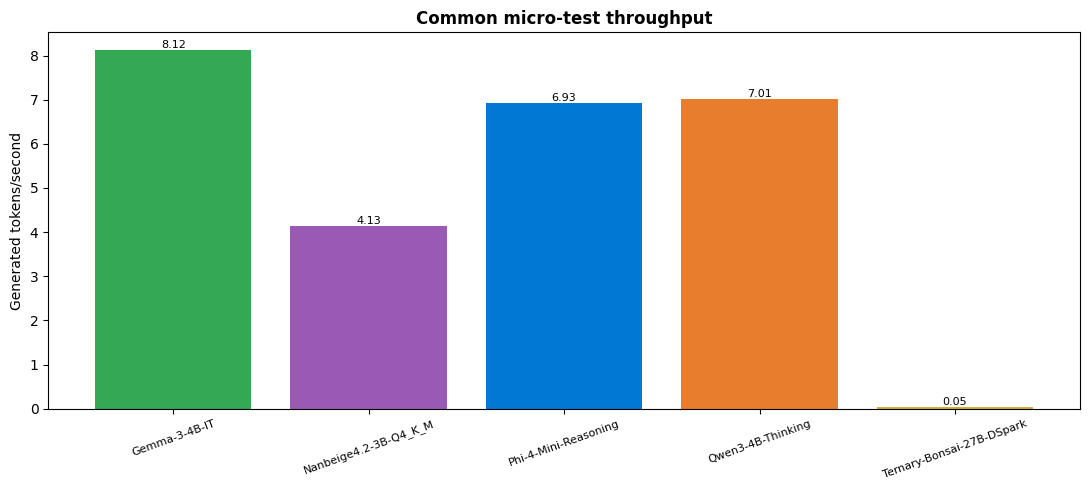

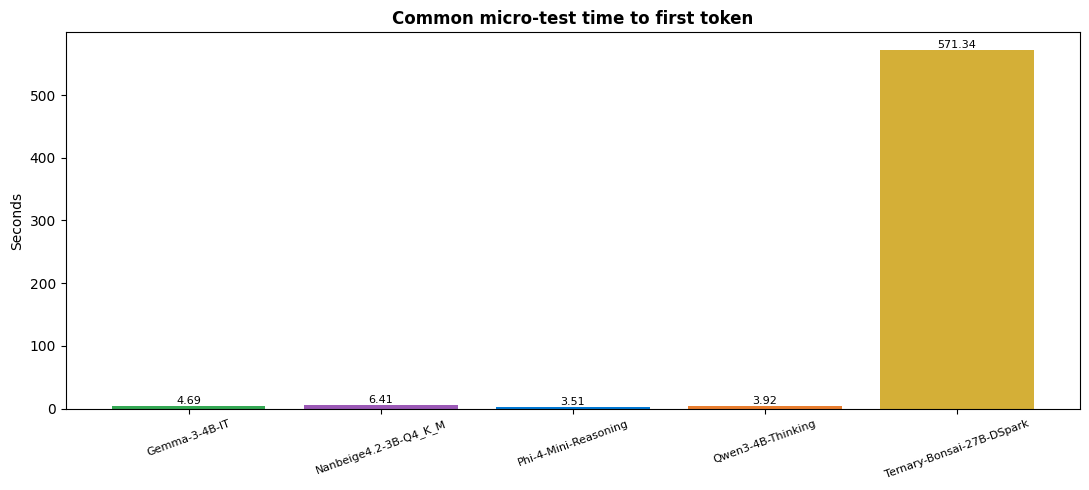

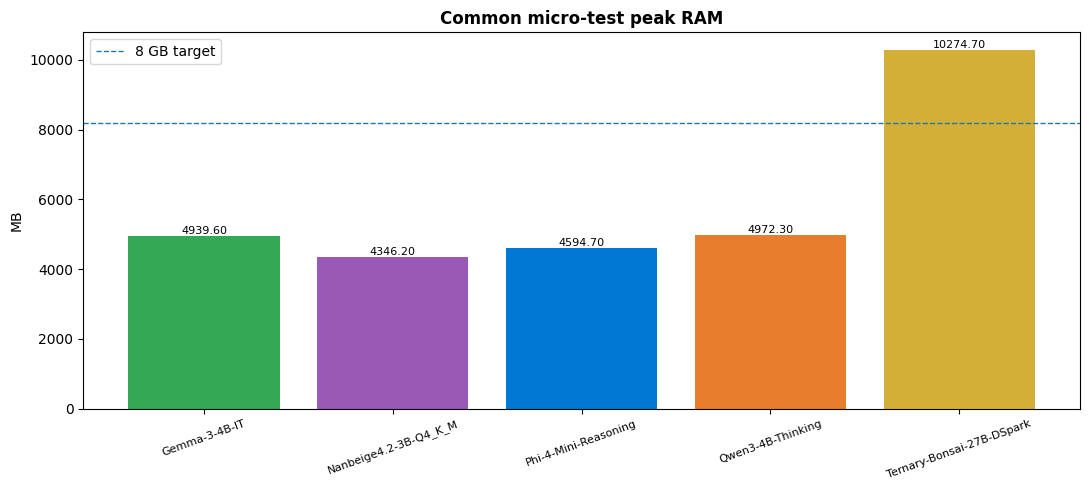

✅ Charts saved


In [9]:
# Plot only successful common-micro measurements. Missing models remain in the CSV/status table.
plot_df = micro_summary[pd.to_numeric(micro_summary["TPS"], errors="coerce").notna()].copy()
if plot_df.empty:
    print("No numeric common-micro results available for plotting.")
else:
    plot_df["TPS"] = pd.to_numeric(plot_df["TPS"], errors="coerce")
    plot_df["TTFT_s"] = pd.to_numeric(plot_df["TTFT_s"], errors="coerce")
    plot_df["PeakRAM_MB"] = pd.to_numeric(plot_df["PeakRAM_MB"], errors="coerce")

    for column, title, ylabel, filename in [
        ("TPS", "Common micro-test throughput", "Generated tokens/second", "mufasar_micro_tps.png"),
        ("TTFT_s", "Common micro-test time to first token", "Seconds", "mufasar_micro_ttft.png"),
        ("PeakRAM_MB", "Common micro-test peak RAM", "MB", "mufasar_micro_ram.png"),
    ]:
        fig, ax = plt.subplots(figsize=(11, 5))
        colors = [MODELS[name]["color"] for name in plot_df["model"]]
        bars = ax.bar(plot_df["model"], plot_df[column], color=colors)
        ax.set_title(title, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=20, labelsize=8)
        if column == "PeakRAM_MB":
            ax.axhline(8192, linestyle="--", linewidth=1, label="8 GB target")
            ax.legend()
        for bar, value in zip(bars, plot_df[column]):
            if pd.notna(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{value:.2f}",
                    ha="center", va="bottom", fontsize=8,
                )
        plt.tight_layout()
        plt.savefig(WORK_DIR / filename, dpi=150, bbox_inches="tight")
        plt.show()

    print("✅ Charts saved")


In [10]:
# Final recommendation uses only successful common-micro rows, which are comparable across models.
valid = micro_summary[pd.to_numeric(micro_summary["TPS"], errors="coerce").notna()].copy()
if valid.empty:
    print("No model produced a comparable common-micro result. Inspect mufasar_benchmark_errors.csv.")
else:
    valid["TPS"] = pd.to_numeric(valid["TPS"], errors="coerce")
    valid["TTFT_s"] = pd.to_numeric(valid["TTFT_s"], errors="coerce")
    valid["PeakRAM_MB"] = pd.to_numeric(valid["PeakRAM_MB"], errors="coerce")

    positive_tps = valid[valid["TPS"] > 0]
    positive_ttft = valid[valid["TTFT_s"] > 0]
    best_tps = (
        positive_tps.loc[positive_tps["TPS"].idxmax(), "model"]
        if not positive_tps.empty else "unavailable"
    )
    fastest_ttft = (
        positive_ttft.loc[positive_ttft["TTFT_s"].idxmin(), "model"]
        if not positive_ttft.empty else "unavailable"
    )
    ram_valid = valid[valid["PeakRAM_MB"].notna()]
    lowest_ram = ram_valid.loc[ram_valid["PeakRAM_MB"].idxmin(), "model"] if not ram_valid.empty else "unavailable"

    lines = [
        "+------------------------------------------------------------------+",
        "|           MUFASAR COMMON-MICRO MODEL RECOMMENDATION            |",
        "+------------------------------------------------------------------+",
        f"| Best throughput : {best_tps:<45}|",
        f"| Fastest TTFT    : {fastest_ttft:<45}|",
        f"| Lowest RAM      : {lowest_ram:<45}|",
        "+------------------------------------------------------------------+",
    ]
    print("\n".join(lines))

print("\nGenerated files:")
for path in sorted(WORK_DIR.glob("mufasar_*")):
    if path.is_file():
        print(" -", path)


+------------------------------------------------------------------+
|           MUFASAR COMMON-MICRO MODEL RECOMMENDATION            |
+------------------------------------------------------------------+
| Best throughput : Gemma-3-4B-IT                                |
| Fastest TTFT    : Phi-4-Mini-Reasoning                         |
| Lowest RAM      : Nanbeige4.2-3B-Q4_K_M                        |
+------------------------------------------------------------------+

Generated files:
 - /kaggle/working/mufasar_benchmark_errors.csv
 - /kaggle/working/mufasar_benchmark_raw.csv
 - /kaggle/working/mufasar_common_micro_summary.csv
 - /kaggle/working/mufasar_full_suite_summary.csv
 - /kaggle/working/mufasar_micro_ram.png
 - /kaggle/working/mufasar_micro_tps.png
 - /kaggle/working/mufasar_micro_ttft.png
 - /kaggle/working/mufasar_model_status.csv
